## Veille technologique

Contexte

Comparaison d'une architecture CNN classique et d'un modèle Transformer pour la classification d'images
## Contexte

Les réseaux de neurones convolutifs (CNN) ont longtemps été les architectures dominantes en vision par ordinateur.
Cependant, l'apparition des Vision Transformers (ViT) a introduit une nouvelle approche basée sur les mécanismes d'attention issus du domaine du NLP.

L'objectif de ce projet est de comparer :

- une architecture CNN classique : ResNet50
- une architecture Transformer : Vision Transformer (ViT)

sur une tâche de classification d'images issue d'un dataset e-commerce Flipkart.

In [21]:
#importation des libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix)
import tensorflow as tf
from google.colab import drive

# ResNet
from tensorflow.keras.applications import ResNet50

# PyTorch / Hugging Face ViT
import torch
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification)

from PIL import Image

In [ ]:
#importation google colab
from google.colab import files
uploaded = files.upload()

Saving flipkart_com-ecommerce_sample_1050.csv to flipkart_com-ecommerce_sample_1050.csv


In [ ]:
#création df"
df = pd.read_csv("flipkart_com-ecommerce_sample_1050.csv")

Le dataset utilisé est un échantillon e-commerce Flipkart contenant environ 1050 images réparties dans plusieurs catégories.

In [ ]:
df

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc,2015-12-01 10:15:43 +0000,http://www.flipkart.com/oren-empower-extra-lar...,Oren Empower Extra Large Self Adhesive Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE88ZGTX65GH4V,1399.0,999.0,958f54f4c46b53c8a0a9b8167d9140bc.jpg,False,Oren Empower Extra Large Self Adhesive Sticker...,No rating available,No rating available,Oren Empower,"{""product_specification""=>[{""key""=>""Number of ..."
1046,fd6cbcc22efb6b761bd564c28928483c,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-large-vinyl...,Wallmantra Large Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIEC889ZD5GDCVQ,4930.0,1896.0,fd6cbcc22efb6b761bd564c28928483c.jpg,False,Wallmantra Large Vinyl Sticker Sticker (Pack o...,No rating available,No rating available,Wallmantra,"{""product_specification""=>[{""key""=>""Number of ..."
1047,5912e037d12774bb73a2048f35a00009,2015-12-01 10:15:43 +0000,http://www.flipkart.com/uberlyfe-extra-large-p...,Uberlyfe Extra Large Pigmented Polyvinyl Films...,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE5UVGW2JWVWCT,4500.0,1449.0,5912e037d12774bb73a2048f35a00009.jpg,False,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,No rating available,No rating available,Uberlyfe,"{""product_specification""=>[{""key""=>""Number of ..."
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-medium-viny...,Wallmantra Medium Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >.

In [ ]:
df=df.copy()

# Préprocessing

Les étapes de préparation doivent rester identiques pour les deux modèles afin d'assurer une comparaison équitable.

Les étapes réalisées :

- Extraction des catégories
- Suppression des variables inutiles
- Préparation des labels
- Préparation des images

In [ ]:
#Preprocessing
def clean_categories(df):
  "Extraction de la catégorie"
  df["product_category"]= (df["product_category_tree"].str.split(" >> ").str[0])

  df["product_catefory"]=(df)["product_category"]=(df["product_category"].str.replace(r'[\[\]\"]', '', regex=True).str.strip())

  return df

In [ ]:
def remove_columns(df):
  "Suprression des variables non utilisés pour le modéle"
  columns_to_drop=[
      "crawl_timestamp",
        "product_url",
        "product_name",
        "pid",
        "retail_price",
        "discounted_price",
        "image",
        "is_FK_Advantage_product",
        "description",
        "product_rating",
        "overall_rating",
        "brand",
        "product_specifications",
        "product_category_tree"
  ]

  return df.drop(columns=columns_to_drop,
        errors="ignore")

In [ ]:
data=clean_categories(df)
data_clean=remove_columns(data)

In [ ]:
data_clean.head()

,uniq_id,product_category,product_catefory
0,55b85ea15a1536d46b7190ad6fff8ce7,Home Furnishing,Home Furnishing
1,7b72c92c2f6c40268628ec5f14c6d590,Baby Care,Baby Care
2,64d5d4a258243731dc7bbb1eef49ad74,Baby Care,Baby Care
3,d4684dcdc759dd9cdf41504698d737d8,Home Furnishing,Home Furnishing
4,6325b6870c54cd47be6ebfbffa620ec7,Home Furnishing,Home Furnishing


In [ ]:
data_clean["product_category"].value_counts()

,count
product_category,
Home Furnishing,150
Baby Care,150
Watches,150
Home Decor & Festive Needs,150
Kitchen & Dining,150
Beauty and Personal Care,150
Computers,150


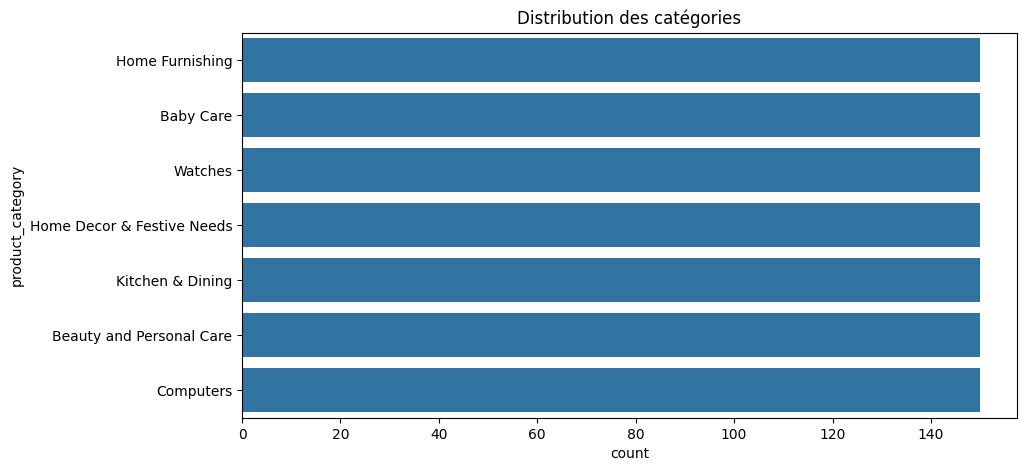

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=data_clean,
    y="product_category")
plt.title(
    "Distribution des catégories")
plt.show()

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
img_dir = "/content/drive/MyDrive/Images"

In [24]:
files = os.listdir(img_dir)
len(files), files[:10]

(1050,
 ['0e73201f6d8807776e1d21c969078289.jpg',
  '0ddc40c08d9a9bafc4d14eddd98db7c0.jpg',
  '10b6738d7058738a9a7d107bbb2833f4.jpg',
  '0e1e3861d54a8a17b7b91f04071a4ca3.jpg',
  '0dc4d2767fe8424a3263ab141884f83d.jpg',
  '0d02f4703fde00645704e15bba23e77d.jpg',
  '0ec47240feda42c63e42f1e9cee60f7a.jpg',
  '0c4718ae90f2889b7021a99ee1cc106c.jpg',
  '0d3e1dc0d38be59e9927e47f152e48aa.jpg',
  '0ca8e323551dd7107ef57ef7c3e77aee.jpg'])

In [38]:
data_clean["image_path"] = (img_dir + "/" + data_clean["uniq_id"] + ".jpg")

In [39]:
data_clean

,uniq_id,product_category,product_catefory,image_path
0,55b85ea15a1536d46b7190ad6fff8ce7,Home Furnishing,Home Furnishing,/content/drive/MyDrive/Images/55b85ea15a1536d4...
1,7b72c92c2f6c40268628ec5f14c6d590,Baby Care,Baby Care,/content/drive/MyDrive/Images/7b72c92c2f6c4026...
2,64d5d4a258243731dc7bbb1eef49ad74,Baby Care,Baby Care,/content/drive/MyDrive/Images/64d5d4a258243731...
3,d4684dcdc759dd9cdf41504698d737d8,Home Furnishing,Home Furnishing,/content/drive/MyDrive/Images/d4684dcdc759dd9c...
4,6325b6870c54cd47be6ebfbffa620ec7,Home Furnishing,Home Furnishing,/content/drive/MyDrive/Images/6325b6870c54cd47...
...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc,Baby Care,Baby Care,/content/drive/MyDrive/Images/958f54f4c46b53c8...
1046,fd6cbcc22efb6b761bd564c28928483c,Baby Care,Baby Care,/content/drive/MyDrive/Images/fd6cbcc22efb6b76...
1047,5912e037d12774bb73a2048f35a00009,Baby Care,Baby Care,/content/drive/MyDrive/Images/5912e037d12774bb...
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,Baby Care,Baby Care,/content/drive/MyDrive/Images/c3edc504d1b4f0ba...


In [27]:
data_path = data_clean.copy()

#fonctions

In [37]:
def montrer_images(df, category, n):
    "Fonction qui affiche n images d'une categorie selectionné"
    images = df[df["product_category"] == category]["image_path"].head(n)
    for image_path in images:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.title(category)
        plt.axis("off")
        plt.show()

In [50]:
def chargement_image(path):
  img=Image.open(path)
  img=img.convert("RGB")
  img=img.resize((224,224))
  return np.array(img)

Encodage des categories

In [40]:
encoder = LabelEncoder()
data_clean["label"] = encoder.fit_transform(
    data_clean["product_category"]
)

Séparation Train / Test

In [44]:
train_df, test_df = train_test_split(data_clean,test_size=0.2,random_state=42,stratify=data_clean["label"])
#utilisation de stratify pour garder les même proportions